# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?

**For the purposes of this lab you MUST use the model building techniques we covered in class.  Failure to do so will automatically result in a 20 point deduction.  I really want you to think about what you are doing and not just paste what you get from ChatGPT (which will often NOT do the correct thing by default).**



In [1]:
import pandas as pd

df = pd.read_csv('Employee_productivity.csv')

df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [5]:
df = pd.read_csv('Employee_productivity.csv')

df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


#### Data Preparation

In [55]:
dept_df = pd.get_dummies(
    df[['Department']],
    drop_first=True,
    dtype=int
)

desk_df = pd.get_dummies(
    df[['DeskLocation']],
    drop_first=True,
    dtype=int
)

y = df['ProductivityScore']

# Employee Productivity Analysis

The purpose of this analysis is to determine which factors have the strongest relationship with employee productivity. The dependent variable is ProductivityScore.

## Years At Company

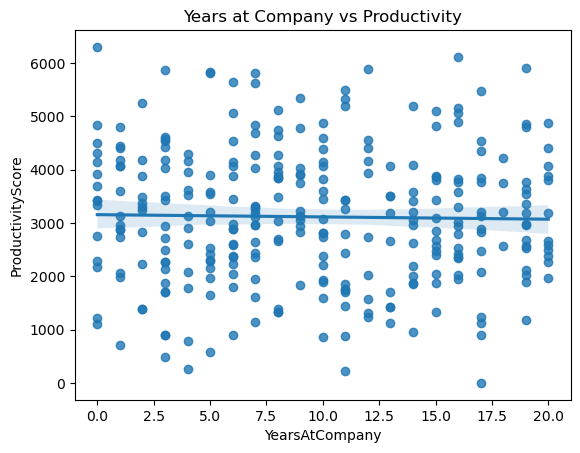

In [7]:
sns.regplot(
    x='YearsAtCompany',
    y='ProductivityScore',
    data=df
)

plt.title('Years at Company vs Productivity')
plt.show()

In [24]:
X = sm.add_constant(df['YearsAtCompany'])

years_model = sm.OLS(y, X).fit()

years_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.1227
Date:                Mon, 22 Jun 2026   Prob (F-statistic):              0.726
Time:                        19:23:41   Log-Likelihood:                -2564.1
No. Observations:                 300   AIC:                             5132.
Df Residuals:                     298   BIC:                             5140.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           3154.6734    136.338     23.139      0.000    2886.366    3422.981
YearsAtCompany    -4.2493     12.132     -0.350      0.726     -28.124      19.625
==============================================================================
Omnibus:                        2.338   Durbin-Watson:                   1.945
Prob(Omnibus):                  0.311   Jarque-Bera (JB):                2.025
Skew:                           0.091   Prob(JB):                        0.363
Kurtosis:                       2.641   Cond. No.                         21.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [35]:
print("Years at Company R²:", years_model.rsquared)

Years at Company R²: 0.0004115291938964205


### Interpretation

The scatterplot shows almost no visible relationship between YearsAtCompany and ProductivityScore. The regression line is nearly flat, indicating that productivity does not consistently increase or decrease as employees spend more time at the company.

The regression model produced an R² value of 0.0004, meaning that YearsAtCompany explains less than 0.1% of the variation in productivity. This extremely low value indicates that years of experience at the company have virtually no predictive power for employee productivity.

Based on these results, there is no evidence to support the claim that either newer employees or more tenured employees are inherently more productive.

## Hours Worked

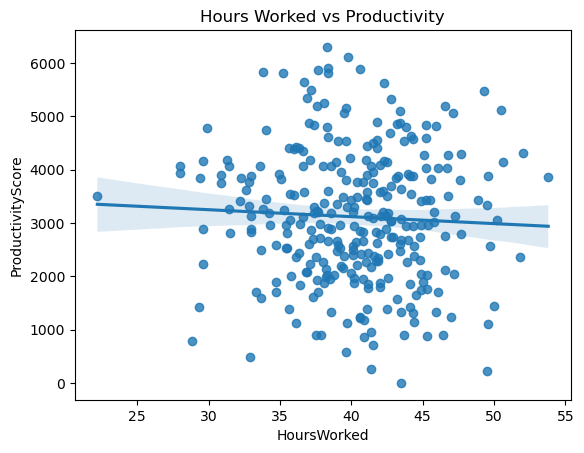

In [8]:
sns.regplot(
    x='HoursWorked',
    y='ProductivityScore',
    data=df
)

plt.title('Hours Worked vs Productivity')
plt.show()

In [29]:
X = sm.add_constant(df['HoursWorked'])

hours_model = sm.OLS(y, X).fit()

hours_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.7768
Date:                Mon, 22 Jun 2026   Prob (F-statistic):              0.379
Time:                        19:35:03   Log-Likelihood:                -2563.7
No. Observations:                 300   AIC:                             5131.
Df Residuals:                     298   BIC:                             5139.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        3638.4153    599.175      6.072      0.000    2459.265    4817.566
HoursWorked   -13.0329     14.787     -0.881      0.379     -42.133      16.068
==============================================================================
Omnibus:                        2.775   Durbin-Watson:                   1.953
Prob(Omnibus):                  0.250   Jarque-Bera (JB):                2.335
Skew:                           0.104   Prob(JB):                        0.311
Kurtosis:                       2.621   Cond. No.                         337.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [36]:
print("Hours Worked R²:", hours_model.rsquared)

Hours Worked R²: 0.0025999350022654077


### Interpretation

The scatterplot shows very little relationship between HoursWorked and ProductivityScore. The data points are widely scattered and the regression line is nearly flat, indicating that employees who work more hours are not consistently more productive than employees who work fewer hours.

The regression model produced an R² value of 0.0026, meaning that HoursWorked explains approximately 0.26% of the variation in productivity. This extremely low R² value indicates that the number of hours worked has virtually no predictive power for employee productivity.

Based on these results, there is no evidence to support the claim that employees must work longer hours or overtime in order to be more productive. Productivity appears to be influenced by other factors rather than simply the number of hours worked.

## Focus Score

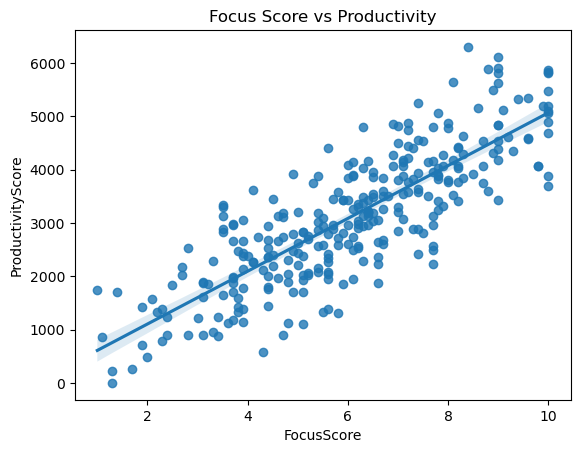

In [9]:
sns.regplot(
    x='FocusScore',
    y='ProductivityScore',
    data=df
)

plt.title('Focus Score vs Productivity')
plt.show()

In [31]:
X = sm.add_constant(df['FocusScore'])

focus_model = sm.OLS(y, X).fit()

focus_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     626.6
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           3.02e-75
Time:                        19:36:49   Log-Likelihood:                -2394.3
No. Observations:                 300   AIC:                             4793.
Df Residuals:                     298   BIC:                             4800.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        114.3813    126.657      0.903      0.367    -134.874     363.636
FocusScore   494.9319     19.772     25.032      0.000     456.021     533.843
==============================================================================
Omnibus:                        0.756   Durbin-Watson:                   2.057
Prob(Omnibus):                  0.685   Jarque-Bera (JB):                0.869
Skew:                           0.076   Prob(JB):                        0.648
Kurtosis:                       2.784   Cond. No.                         20.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [37]:
print("Focus Score R²:", focus_model.rsquared)

Focus Score R²: 0.6776960770307456


### Interpretation

The scatterplot shows a strong positive relationship between FocusScore and ProductivityScore. As employee focus increases, productivity also increases. The regression line has a clear upward trend, indicating a strong linear relationship between the two variables.

The regression model produced an R² value of 0.6777, meaning that approximately 67.8% of the variation in productivity can be explained by FocusScore alone. This was the highest R² value among the variables tested.

Based on these results, focus is the strongest predictor of employee productivity. The data supports employee concerns that distractions and difficulty concentrating negatively affect productivity. Improving employee focus may have the greatest impact on overall productivity within the company.

## Meetings

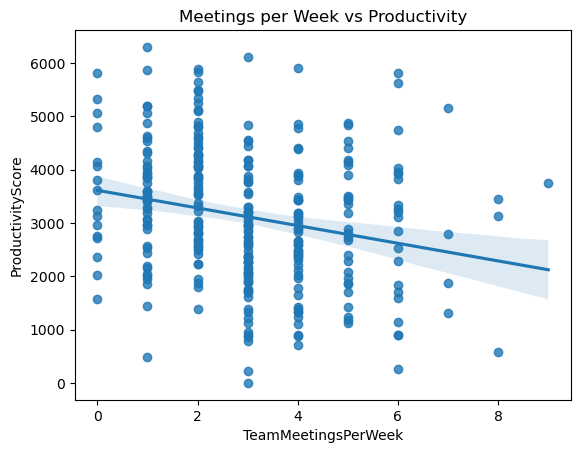

In [14]:
sns.regplot(
    x='TeamMeetingsPerWeek',
    y='ProductivityScore',
    data=df
)

plt.title('Meetings per Week vs Productivity')
plt.show()

In [33]:
X = sm.add_constant(df['TeamMeetingsPerWeek'])

meetings_model = sm.OLS(y, X).fit()

meetings_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     17.09
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           4.63e-05
Time:                        19:39:41   Log-Likelihood:                -2555.8
No. Observations:                 300   AIC:                             5116.
Df Residuals:                     298   BIC:                             5123.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                3611.2745    139.247     25.934      0.000    3337.243    3885.306
TeamMeetingsPerWeek  -165.5197     40.036     -4.134      0.000    -244.309     -86.730
==============================================================================
Omnibus:                        2.592   Durbin-Watson:                   1.991
Prob(Omnibus):                  0.274   Jarque-Bera (JB):                2.468
Skew:                           0.157   Prob(JB):                        0.291
Kurtosis:                       2.686   Cond. No.                         7.33
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [38]:
print("Meetings R²:", meetings_model.rsquared)

Meetings R²: 0.05424465123148969


### Interpretation

The scatterplot shows a negative relationship between TeamMeetingsPerWeek and ProductivityScore. As the number of weekly meetings increases, employee productivity tends to decrease. The regression line slopes downward, indicating that employees who attend more meetings generally have lower productivity scores.

The regression model produced an R² value of 0.0542, meaning that TeamMeetingsPerWeek explains approximately 5.4% of the variation in productivity. While this is a relatively small amount of the total variation, it is considerably larger than the relationships observed for YearsAtCompany and HoursWorked.

The negative coefficient of -165.52 suggests that each additional meeting per week is associated with an average decrease of approximately 166 productivity points. The p-value of 0.000 indicates that this relationship is statistically significant.

These results provide some support for employee concerns regarding excessive meetings. Although meetings are not nearly as influential as employee focus, increasing the number of meetings appears to have a measurable negative impact on productivity.

## Department

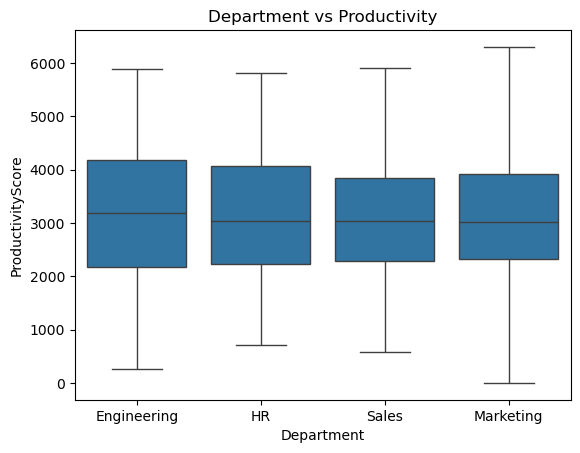

In [16]:
sns.boxplot(
    x='Department',
    y='ProductivityScore',
    data=df
)

plt.title('Department vs Productivity')
plt.show()

In [42]:
X = sm.add_constant(dept_df)

department_model = sm.OLS(y, X).fit()

department_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.009
Method:                 Least Squares   F-statistic:                   0.08064
Date:                Mon, 22 Jun 2026   Prob (F-statistic):              0.971
Time:                        19:51:32   Log-Likelihood:                -2564.0
No. Observations:                 300   AIC:                             5136.
Df Residuals:                     296   BIC:                             5151.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 3163.4292    144.850     21.839      0.000    2878.364    3448.495
Department_HR          -33.3728    201.622     -0.166      0.869    -430.167     363.422
Department_Marketing   -91.1478    206.971     -0.440      0.660    -498.469     316.174
Department_Sales       -75.9887    206.247     -0.368      0.713    -481.884     329.907
==============================================================================
Omnibus:                        2.318   Durbin-Watson:                   1.941
Prob(Omnibus):                  0.314   Jarque-Bera (JB):                2.044
Skew:                           0.100   Prob(JB):                        0.360
Kurtosis:                       2.648   Cond. No.                         4.79
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [43]:
print("Department R²:", department_model.rsquared)

Department R²: 0.0008165860311227791


### Interpretation

The boxplot shows some differences in productivity scores between departments, but there is considerable overlap among the groups. Employees from different departments demonstrate similar ranges of productivity scores.

The Department model produced an R² value of 0.0008, meaning that department explains less than 0.1% of the variation in employee productivity. This extremely low R² value indicates that an employee's department has virtually no predictive power for productivity.

These results suggest that productivity differences are not driven by the department in which employees work. Employees in Engineering, Human Resources, Sales, and Marketing appear to perform similarly overall, indicating that other factors have a much greater influence on productivity.

## Desk Location

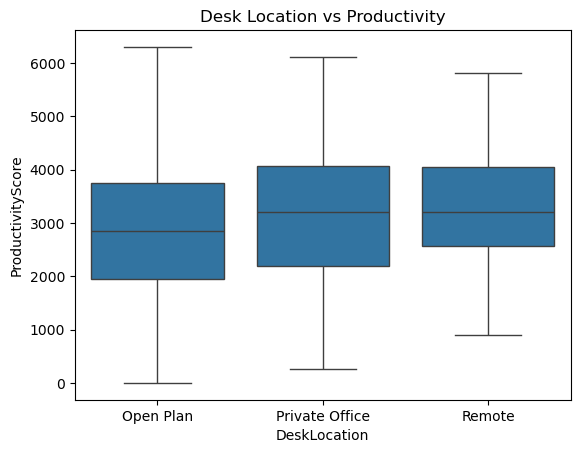

In [17]:
sns.boxplot(
    x='DeskLocation',
    y='ProductivityScore',
    data=df
)

plt.title('Desk Location vs Productivity')
plt.show()

In [45]:
X = sm.add_constant(desk_df)

desk_model = sm.OLS(y, X).fit()

desk_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     3.242
Date:                Mon, 22 Jun 2026   Prob (F-statistic):             0.0405
Time:                        19:52:40   Log-Likelihood:                -2560.9
No. Observations:                 300   AIC:                             5128.
Df Residuals:                     297   BIC:                             5139.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================================
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                        2863.1937    122.119     23.446      0.000    2622.865    3103.523
DeskLocation_Private Office   363.6361    171.081      2.126      0.034      26.951     700.321
DeskLocation_Remote           404.2439    178.831      2.260      0.025      52.308     756.180
==============================================================================
Omnibus:                        2.481   Durbin-Watson:                   1.974
Prob(Omnibus):                  0.289   Jarque-Bera (JB):                2.216
Skew:                           0.118   Prob(JB):                        0.330
Kurtosis:                       2.651   Cond. No.                         3.69
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [46]:
print("Desk Location R²:", desk_model.rsquared)

Desk Location R²: 0.021365966750715448


### Interpretation

The boxplot shows some variation in productivity scores among the different desk locations. Employees working remotely, in private offices, and in open-plan environments exhibit slightly different productivity levels.

The Desk Location model produced an R² value of 0.0214, meaning that desk location explains approximately 2.1% of the variation in productivity. While this relationship is stronger than those observed for YearsAtCompany, HoursWorked, and Department, it remains relatively weak.

These results suggest that desk location has a small impact on employee productivity. Remote employees appear to have somewhat lower productivity scores than employees working in office environments. However, desk location is considerably less important than employee focus when predicting productivity.

## Final Combinied Model

In [20]:
model_df = pd.get_dummies(
    df,
    columns=['Department', 'DeskLocation'],
    drop_first=True,
    dtype=int
)

X = model_df.drop(columns=['ProductivityScore'])

X = sm.add_constant(X)

y = model_df['ProductivityScore']

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.675
Method:                 Least Squares   F-statistic:                     70.11
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           1.53e-67
Time:                        18:47:54   Log-Likelihood:                -2390.8
No. Observations:                 300   AIC:                             4802.
Df Residuals:                     290   BIC:                             4839.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
===============================================================================================
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                         255.7046    399.258      0.640      0.522    -530.105    1041.515
HoursWorked                    -4.6642      8.541     -0.546      0.585     -21.474      12.146
FocusScore                    512.7193     21.748     23.575      0.000     469.915     555.523
YearsAtCompany                  3.4008      6.992      0.486      0.627     -10.360      17.162
TeamMeetingsPerWeek            27.1706     24.914      1.091      0.276     -21.864      76.206
Department_HR                 -93.3984    115.183     -0.811      0.418    -320.100     133.303
Department_Marketing         -136.2405    118.380     -1.151      0.251    -369.234      96.753
Department_Sales              -49.8174    117.871     -0.423      0.673    -281.809     182.174
DeskLocation_Private Office  -103.4120    100.491     -1.029      0.304    -301.197      94.373
DeskLocation_Remote          -229.7530    106.847     -2.150      0.032    -440.047     -19.459
==============================================================================
Omnibus:                        0.168   Durbin-Watson:                   2.043
Prob(Omnibus):                  0.920   Jarque-Bera (JB):                0.295
Skew:                           0.024   Prob(JB):                        0.863
Kurtosis:                       2.854   Cond. No.                         412.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Final Results and Recommendations

The analysis found that FocusScore had the strongest linear relationship with employee productivity. The FocusScore model produced an R² value of 0.6777, meaning that approximately 67.8% of the variation in productivity can be explained by employee focus alone. This was substantially higher than every other variable included in the analysis.

YearsAtCompany and HoursWorked showed almost no relationship with productivity, producing R² values of 0.0004 and 0.0026, respectively. These results indicate that neither employee tenure nor the number of hours worked significantly impacts productivity.

TeamMeetingsPerWeek demonstrated a small but statistically significant negative relationship with productivity, producing an R² value of 0.0542. The model suggests that employees who attend more meetings tend to have lower productivity scores.

Department and DeskLocation explained only a small portion of productivity differences, with R² values of 0.0008 and 0.0214, respectively. While remote employees appeared to have slightly lower productivity scores, the impact of desk location was relatively weak compared to employee focus.

The final combined regression model produced an R² value of 0.685, indicating that approximately 68.5% of the variation in employee productivity can be explained by the variables included in the model. FocusScore remained the strongest predictor within the combined model.

Based on these findings, the company should prioritize improving employee focus, reducing unnecessary meetings, and evaluating workplace environments that may contribute to distractions. Increasing hours worked or relying on employee tenure does not appear to improve productivity.

# Further Investigation

Additional analyses were conducted to explore possible relationships between workplace factors and employee focus that may indirectly influence productivity.

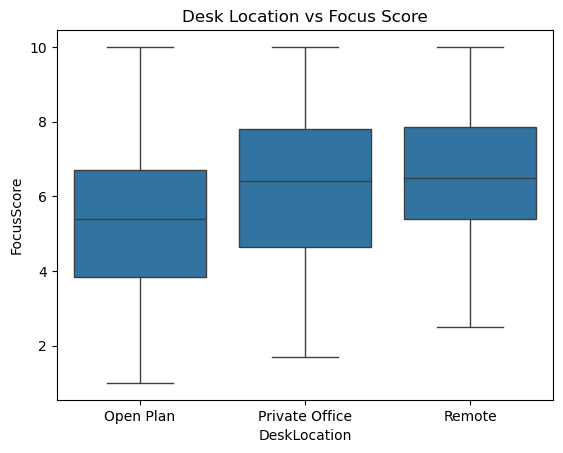

In [47]:
sns.boxplot(
    x='DeskLocation',
    y='FocusScore',
    data=df
)

plt.title('Desk Location vs Focus Score')
plt.show()

In [48]:
df.groupby('DeskLocation')['FocusScore'].mean()

DeskLocation
Open Plan         5.374757
Private Office    6.277570
Remote            6.588889
Name: FocusScore, dtype: float64

In [49]:
y_focus = df['FocusScore']

desk_focus = pd.get_dummies(
    df[['DeskLocation']],
    drop_first=True,
    dtype=int
)

X = sm.add_constant(desk_focus)

focus_location_model = sm.OLS(y_focus, X).fit()

focus_location_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             FocusScore   R-squared:                       0.061
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     9.638
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           8.80e-05
Time:                        19:57:53   Log-Likelihood:                -635.01
No. Observations:                 300   AIC:                             1276.
Df Residuals:                     297   BIC:                             1287.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================================
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                           5.3748      0.199     27.013      0.000       4.983       5.766
DeskLocation_Private Office     0.9028      0.279      3.239      0.001       0.354       1.451
DeskLocation_Remote             1.2141      0.291      4.167      0.000       0.641       1.788
==============================================================================
Omnibus:                        8.316   Durbin-Watson:                   1.981
Prob(Omnibus):                  0.016   Jarque-Bera (JB):                4.473
Skew:                          -0.017   Prob(JB):                        0.107
Kurtosis:                       2.403   Cond. No.                         3.69
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [50]:
print(
    "R²:",
    round(focus_location_model.rsquared,4)
)

R²: 0.0609


In [52]:
df.groupby('DeskLocation')['TeamMeetingsPerWeek'].mean()

DeskLocation
Open Plan         2.932039
Private Office    2.962617
Remote            3.133333
Name: TeamMeetingsPerWeek, dtype: float64

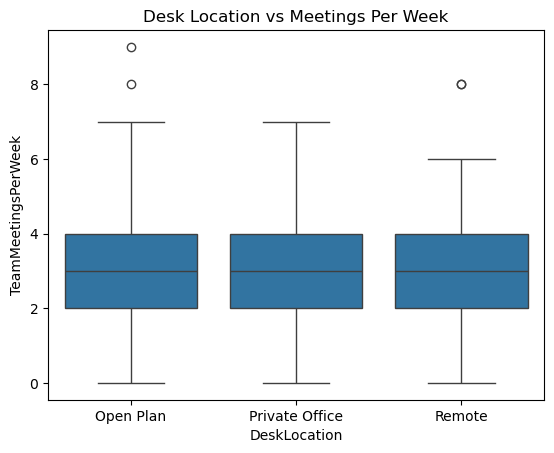

In [51]:
sns.boxplot(
    x='DeskLocation',
    y='TeamMeetingsPerWeek',
    data=df
)

plt.title('Desk Location vs Meetings Per Week')
plt.show()

### Interpretation

This additional analysis examined whether desk location and meetings influences employee focus levels. Since FocusScore was identified as the strongest predictor of productivity, understanding factors that affect focus may help explain differences in productivity.

The boxplot and average focus scores show clear differences between work environments. Employees working in open-plan offices had the lowest average focus score of 5.37. Employees working in private offices had an average focus score of 6.28, while remote employees had the highest average focus score of 6.59.

These results suggest that desk location may indirectly affect productivity by influencing employee focus. While desk location itself explained only a small amount of the variation in productivity, employees working in open-plan environments consistently reported lower focus scores. Since FocusScore was the strongest predictor of productivity in the original models, lower focus levels in open-plan environments may contribute to reduced productivity.

This additional analysis supports employee concerns that distractions within open work environments can negatively impact concentration and productivity. The findings suggest that reducing workplace distractions or providing quieter work environments may improve employee focus and ultimately increase productivity.

Remote employees attended an average of 3.13 meetings per week, compared to 2.96 for private office employees and 2.93 for employees in open-plan offices. This suggests that meeting frequency does not explain the lower productivity observed among remote workers.

While remote employees reported the highest focus scores, the final model still indicated slightly lower productivity for remote workers. The dataset does not contain enough information to determine the cause of this relationship, suggesting that additional variables such as communication, collaboration, or work responsibilities may influence remote productivity.  --  Bad news for all of us Remote Workers 